[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Roman-HLIS-Cosmology-PIT/slimfarmer/blob/main/doc/Flux_error_validation_colab.ipynb)

# Flux_error_validation
In this notebook, we will use idealized simulation to validate the flux_err calculation in slimfarmer and also point out a serious problem in the correlated noise scenario.

**Part 1** — White (uncorrelated) Gaussian noise: `flux_err` should match `sigma_MC`.

**Part 2** — Correlated noise from real Roman data: `flux_err` is underestimated relative to `sigma_MC` because the weight map assumes white noise.


In [1]:
#uncomment for colab
"""
!apt-get install -y swig zlib1g-dev libcfitsio-dev libcairo2-dev \
    libjpeg-dev libnetpbm10-dev netpbm
!pip install numpy scipy matplotlib astropy
!git clone https://github.com/dstndstn/astrometry.net.git /content/astrometry.net
%cd /content/astrometry.net
!make
!make py
!make extra
!make install INSTALL_DIR=/content/astrometry-install
import sys, os
os.environ['PYTHONPATH'] = '/content/astrometry-install/lib/python'
sys.path.insert(0, '/content/astrometry-install/lib/python')

# Cell 5: Verify astrometry.util works
from astrometry.util.ttime import Time
print("astrometry.util OK!")
!git clone https://github.com/dstndstn/tractor.git
%cd tractor
!python setup.py build_ext --inplace --with-cython
!pip install .  --no-build-isolation
#Install all package
!pip install git+https://github.com/esheldon/fitsio.git#egg=fitsio
!pip install galsim
import tractor
print("Tractor imported successfully!")
!pip install git+https://github.com/Roman-HLIS-Cosmology-PIT/slimfarmer.git
%cd /content
!git clone https://github.com/Roman-HLIS-Cosmology-PIT/pyimcom.git
%cd /content/pyimcom
# Install dependencies then the package
!pip install -r requirements.txt
!pip install .
%cd /content
"""

'\n!apt-get install -y swig zlib1g-dev libcfitsio-dev libcairo2-dev     libjpeg-dev libnetpbm10-dev netpbm\n!pip install numpy scipy matplotlib astropy\n!git clone https://github.com/dstndstn/astrometry.net.git /content/astrometry.net\n%cd /content/astrometry.net\n!make\n!make py\n!make extra\n!make install INSTALL_DIR=/content/astrometry-install\nimport sys, os\nos.environ[\'PYTHONPATH\'] = \'/content/astrometry-install/lib/python\'\nsys.path.insert(0, \'/content/astrometry-install/lib/python\')\n\n# Cell 5: Verify astrometry.util works\nfrom astrometry.util.ttime import Time\nprint("astrometry.util OK!")\n!git clone https://github.com/dstndstn/tractor.git\n%cd tractor\n!python setup.py build_ext --inplace --with-cython\n!pip install .  --no-build-isolation\n#Install all package\n!pip install git+https://github.com/esheldon/fitsio.git#egg=fitsio\n!pip install galsim\nimport tractor\nprint("Tractor imported successfully!")\n!pip install git+https://github.com/Roman-HLIS-Cosmology-PIT/s

In [2]:
import sys
sys.path.insert(0, '../slimfarmer/')


Now I have download all the package.
Let's now download the necessary files

In [3]:
!wget -O im3x2-H1_00_00.cpr.fits.gz "https://www.dropbox.com/scl/fo/m0p553ypvkpsdfd851sul/AJYJ9r0_pX0C37PWAqzOphE/H1_coadds_Grp0/im3x2-H1_00_00.cpr.fits.gz?rlkey=gsij7sy1zok89poz4wr3xzmia&st=aygyeyo3&dl=0"


--2026-04-03 13:02:09--  https://www.dropbox.com/scl/fo/m0p553ypvkpsdfd851sul/AJYJ9r0_pX0C37PWAqzOphE/H1_coadds_Grp0/im3x2-H1_00_00.cpr.fits.gz?rlkey=gsij7sy1zok89poz4wr3xzmia&st=aygyeyo3&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc37084752f677018a0eea70d977.dl.dropboxusercontent.com/cd/0/inline/C94v93IVRNT4eOsCPxL5QQWVTxe223G8R5omGuTpljB18r355a4APGhDIm1PlHFvrRvZ_SSg3EIT-Q4itjuMxVDPLO5dWxHS0S8Xb5k9K18nJ6SiizO07qlpVQrvbmJsQiAckClaxBEV7BnUO4rOxy9f/file# [following]
--2026-04-03 13:02:10--  https://uc37084752f677018a0eea70d977.dl.dropboxusercontent.com/cd/0/inline/C94v93IVRNT4eOsCPxL5QQWVTxe223G8R5omGuTpljB18r355a4APGhDIm1PlHFvrRvZ_SSg3EIT-Q4itjuMxVDPLO5dWxHS0S8Xb5k9K18nJ6SiizO07qlpVQrvbmJsQiAckClaxBEV7BnUO4rOxy9f/file
Resolving uc37084752f677018a0eea70d977.dl.dropboxusercontent.com (uc3708475

In [4]:
import sys, warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import galsim
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval, ImageNormalize
import slimfarmer
from scipy import stats
print(f'GalSim  {galsim.__version__}')
print(f'slimfarmer {slimfarmer.__version__}')


GalSim  2.8.3
slimfarmer 1.1.0


In [5]:
# First let's define some key parameters.
rng = galsim.BaseDeviate(42)
PIXEL_SCALE  = 0.049 # arcsec
STAMP_SIZE   = 125
PSF_FWHM     = 0.24 # arcsec
EXPTIME      = 107.0 *4

SKY_RATE     = 0.00
SKY_LEVEL    = SKY_RATE * EXPTIME
READ_NOISE   = 2.8
NOISE_SIGMA  = float(np.sqrt(SKY_LEVEL + READ_NOISE**2))
NOISE_SIGMA_RATE = NOISE_SIGMA / EXPTIME

ZP_RATE = 23.0
BAND    = 'F158'

SCI_PATH      = './galsim_sci.fits'
WHT_PATH      = './galsim_wht.fits'
EFF_GAIN_PATH = './galsim_eff_gain.fits'
PSF_PATH      = './galsim_psf.fits'
OUT_PATH      = './galsim_cat.fits'

print(f'EXPTIME          : {EXPTIME:.0f} s')
print(f'Zeropoint (rate) : {ZP_RATE} AB mag at 1 e-/s')
print(f'READ_NOISE       : {READ_NOISE:.0f} e/pix')
print(f'Noise floor      : {NOISE_SIGMA_RATE:.6f} e-/s/pix')


EXPTIME          : 428 s
Zeropoint (rate) : 23.0 AB mag at 1 e-/s
READ_NOISE       : 3 e/pix
Noise floor      : 0.006542 e-/s/pix


## 1. PSF

In [6]:
psf = galsim.Gaussian(fwhm=PSF_FWHM)
psf_img = galsim.Image(39, 39, scale=PIXEL_SCALE)
psf.drawImage(image=psf_img, method='no_pixel')
psf_arr = psf_img.array
psf_arr /= psf_arr.sum()
fits.writeto(PSF_PATH, psf_arr.astype(np.float32), overwrite=True)
print(f'PSF stamp: {psf_arr.shape}, peak={psf_arr.max():.4f}')


PSF stamp: (39, 39), peak=0.0368


## 2. Truth catalog

In [7]:
RA0, DEC0 = 150.0, 2.0

truth_sources = [
    (  0.0,  0.0, 0.2, 1.0, 21.0, 'ExpGalaxy'),
]

def mag_to_flux(mag, zp=ZP_RATE):
    return 10 ** (-(mag - zp) / 2.5)

print(f'{"dx":>6} {"dy":>6} {"hlr":>5} {"n":>4} {"mag":>5} {"flux_e/s":>10}  label')
for dx, dy, hlr, n, mag, lbl in truth_sources:
    print(f'{dx:6.1f} {dy:6.1f} {hlr:5.2f} {n:4.1f} {mag:5.1f} {mag_to_flux(mag):10.3f}  {lbl}')


    dx     dy   hlr    n   mag   flux_e/s  label
   0.0    0.0  0.20  1.0  21.0      6.310  ExpGalaxy


In [8]:
from tractor.mixture_profiles import exp_amp, exp_var, dev_amp, dev_var
def _make_gal(lbl, hlr, n, flux):
    if lbl == 'PointSource':
        return galsim.DeltaFunction(flux=flux)
    elif lbl == 'ExpGalaxy':
        amps, vars_ = exp_amp, np.array(exp_var)
    elif lbl == 'DevGalaxy':
        amps, vars_ = dev_amp, np.array(dev_var)
    else:
        return galsim.Sersic(n=n, half_light_radius=hlr, flux=flux)
    return galsim.Sum([galsim.Gaussian(flux=a * flux, sigma=np.sqrt(v) * hlr)
                       for a, v in zip(amps, vars_)])


In [9]:
def write_fits(sci_arr):
    N = sci_arr.shape[0]
    hdr = fits.Header()
    hdr['NAXIS'] = 2; hdr['NAXIS1'] = N; hdr['NAXIS2'] = N
    hdr['CTYPE1'] = 'RA---TAN'; hdr['CTYPE2'] = 'DEC--TAN'
    hdr['CRPIX1'] = (N + 1) / 2; hdr['CRPIX2'] = (N + 1) / 2
    hdr['CRVAL1'] = RA0; hdr['CRVAL2'] = DEC0
    hdr['CDELT1'] = -PIXEL_SCALE / 3600.; hdr['CDELT2'] = PIXEL_SCALE / 3600.
    hdr['CUNIT1'] = 'deg'; hdr['CUNIT2'] = 'deg'
    hdr['BUNIT'] = 'e-/s'; hdr['EXPTIME'] = EXPTIME
    fits.writeto(SCI_PATH, sci_arr.astype(np.float32), hdr, overwrite=True)
    wht_arr = np.full_like(sci_arr, 1.0 / NOISE_SIGMA_RATE**2, dtype=np.float32)
    fits.writeto(WHT_PATH, wht_arr, hdr, overwrite=True)
    eff_gain_arr = np.full_like(sci_arr, EXPTIME, dtype=np.float32)
    fits.writeto(EFF_GAIN_PATH, eff_gain_arr, hdr, overwrite=True)
    return hdr


In [10]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from tqdm.auto import tqdm

def run_mc(render_fn, N_REAL=30):
    """Run N_REAL realisations using render_fn(img_noiseless, rng_i) -> sci_arr."""
    N = STAMP_SIZE
    wcs_hdr = WCS(fits.getheader(SCI_PATH))
    truth_ra_arr  = np.array([wcs_hdr.all_pix2world((N-1)/2 + dx/PIXEL_SCALE,
                                                      (N-1)/2 + dy/PIXEL_SCALE, 0)[0]
                               for dx, dy, *_ in truth_sources])
    truth_dec_arr = np.array([wcs_hdr.all_pix2world((N-1)/2 + dx/PIXEL_SCALE,
                                                      (N-1)/2 + dy/PIXEL_SCALE, 0)[1]
                               for dx, dy, *_ in truth_sources])
    tru_c = SkyCoord(truth_ra_arr, truth_dec_arr, unit='deg')

    mc_cfg = slimfarmer.Config(thresh=10.0, noshot=True, fixed_reff=truth_sources[0][2],model_priors = {'pos': 0.1*u.arcsec, 'reff':'freeze', 'shape': 'none', 'fracDev': 'none'})
    img_noiseless = galsim.Image(N, N, scale=PIXEL_SCALE)
    img_noiseless.setZero()
    for dx, dy, hlr, n, mag, lbl in truth_sources:
        flux = mag_to_flux(mag) * EXPTIME
        galsim.Convolve([_make_gal(lbl, hlr, n, flux), psf]).shift(dx=dx, dy=dy).drawImage(
            image=img_noiseless, method='auto', add_to_image=True)

    mc_ratios          = [[] for _ in truth_sources]
    mc_flux            = [[] for _ in truth_sources]
    mc_flux_err        = [[] for _ in truth_sources]
    mc_flux_err_des    = [[] for _ in truth_sources]

    for seed in tqdm(range(N_REAL), desc='realisations'):
        rng_i = galsim.BaseDeviate(seed)
        sci_arr = render_fn(img_noiseless, rng_i)
        hdr = write_fits(sci_arr)
        try:
            cat_i, img_i= slimfarmer.run_photometry(
                science_path=SCI_PATH, weight_path=WHT_PATH, eff_gain_path=EFF_GAIN_PATH,
                psf_path=PSF_PATH, band=BAND, zeropoint=ZP_RATE, config=mc_cfg, ncpus=0)
            #print(cat_i['name'])
            #assert(cat_i['name']=="ExpGalaxy")
            #assert((cat_i['ra']-150)**2+(cat_i['dec']-2)**2<1E-10)
            #assert((np.abs(cat_i['ee2'])<1E-2))
        except:
            continue
        cat_c = SkyCoord(cat_i['ra'], cat_i['dec'], unit='deg')
        idx_c, d2d_c, _ = cat_c.match_to_catalog_sky(tru_c)
        sep_as = d2d_c.to(u.arcsec).value
        for ti, (dx, dy, hlr, n, mag, lbl) in enumerate(truth_sources):
            mask = (idx_c == ti) & (sep_as < 0.2)
            if not mask.any():
                continue
            best = np.where(mask)[0][np.argmin(sep_as[mask])]
            obs = float(cat_i[f'{BAND}_flux'][best])
            mc_ratios[ti].append(obs / mag_to_flux(mag))
            mc_flux[ti].append(obs)
            mc_flux_err[ti].append(float(cat_i[f'{BAND}_flux_err_noshot'][best]))
            mc_flux_err_des[ti].append(float(cat_i[f'{BAND}_flux_err_des'][best]))

    return mc_ratios, mc_flux, mc_flux_err, mc_flux_err_des


In [11]:
def plot_mc_results(mc_ratios, mc_flux, mc_flux_err, mc_flux_err_des, title=''):
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(truth_sources)))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ti, ((dx, dy, hlr, n, mag, lbl), col) in enumerate(zip(truth_sources, colors)):
        ratios = np.array(mc_ratios[ti])
        flux   = np.array(mc_flux[ti])
        ferr   = np.array(mc_flux_err[ti])
        ferr_des = np.array(mc_flux_err_des[ti])
        if len(flux) < 3:
            continue

        sigma_mc  = stats.median_abs_deviation(flux, scale='normal')
        mean_ferr     = np.mean(ferr)
        mean_ferr_des = np.mean(ferr_des)

        # Left: flux ratio histogram
        ax = axes[0]
        bins = np.linspace(0.85, 1.15, 25)
        ax.hist(ratios, bins=bins, color=col, alpha=0.7, edgecolor='white', lw=0.4)
        ax.axvline(np.median(ratios), color='red', lw=1.5)
        nmad = 1.4826 * np.median(np.abs(ratios - np.median(ratios)))
        ax.set_xlabel('obs / true flux')
        ax.set_ylabel('count')
        ax.set_title(f'{lbl}  mag={mag:.1f}\nmedian={np.median(ratios):.3f}  NMAD={nmad:.3f}')

        # Rig
        ax = axes[1]

        violin_data = [ferr, ferr_des]
        labels = ['flux_err\n(Tractor[Fisher])', 'flux_err_des\n(DES [Montecarlo])']
        vp = ax.violinplot(violin_data, positions=[1, 2], showmedians=True, showextrema=True)

        # Style the violins
        violin_colors = ['steelblue', 'darkorange']
        for body, col in zip(vp['bodies'], violin_colors):
            body.set_facecolor(col)
            body.set_alpha(0.7)
            body.set_edgecolor('k')
            body.set_linewidth(0.5)
        vp['cmedians'].set_color('white')
        vp['cmedians'].set_linewidth(1.5)
        vp['cmaxes'].set_color('k')
        vp['cmins'].set_color('k')
        vp['cbars'].set_color('k')

        # sigma_MC as a horizontal reference line
        ax.axhline(sigma_mc, color='crimson', lw=1.5, linestyle='--', label=f'sigma_MC = {sigma_mc:.3f}')
        ax.legend(fontsize=8)

        # Annotate medians
        for pos, arr in zip([1, 2], violin_data):
            med = np.median(arr)
            ax.text(pos, med * 1.02, f'{med:.3f}', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

        ax.set_xticks([1, 2])
        ax.set_xticklabels(labels)
        ax.set_ylabel('flux error  [e-/s]')
        ax.set_title(
            f'Error comparison\n'
            f'flux_err/sigma_MC = {mean_ferr/sigma_mc:.3f}   '
            f'flux_err_des/sigma_MC = {mean_ferr_des/sigma_mc:.3f}'
        )
        ax.set_xlim(0.5, 2.5)
        ax.set_ylim(0, max(np.max(ferr), np.max(ferr_des),sigma_mc) * 1.3)
        print(f'{lbl}  mag={mag:.1f}:')
        print(f'  sigma_MC       = {sigma_mc:.4f} e-/s')
        print(f'  flux_err       = {mean_ferr:.4f} e-/s  (ratio {mean_ferr/sigma_mc:.3f})')
        print(f'  flux_err_des   = {mean_ferr_des:.4f} e-/s  (ratio {mean_ferr_des/sigma_mc:.3f})')

    if title:
        fig.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


---
# Part 1: White (uncorrelated) Gaussian noise
In all these calculations, I am going to ignore self-Poisson shot noise. This is because it will be hard to draw correlated shot noise in the correlated case  

Noise model: `GaussianNoise(sigma=READ_NOISE)` — spatially independent pixels.  
The weight map `1/NOISE_SIGMA_RATE²` exactly matches the noise, so slimfarmer's Fisher error estimate should agree with the MC scatter.


### Render science image

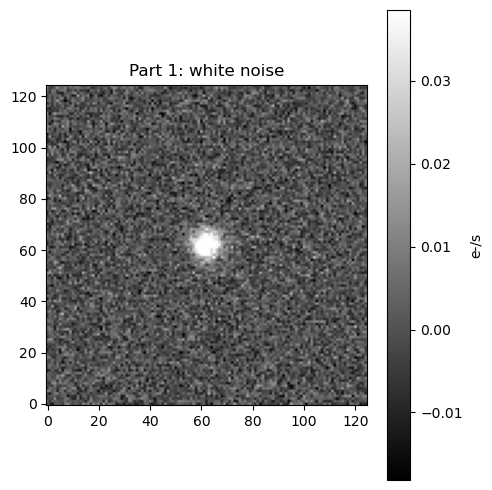

Peak SNR ~ 11.5


In [12]:
N = STAMP_SIZE
full_img = galsim.Image(N, N, scale=PIXEL_SCALE)
full_img.setZero()
for dx, dy, hlr, n, mag, lbl in truth_sources:
    flux = mag_to_flux(mag) * EXPTIME
    galsim.Convolve([_make_gal(lbl, hlr, n, flux), psf]).shift(dx=dx, dy=dy).drawImage(
        image=full_img, method='auto', add_to_image=True)

full_img.addNoise(galsim.GaussianNoise(rng=rng, sigma=READ_NOISE))
full_img /= EXPTIME

sci_arr = full_img.array
hdr = write_fits(sci_arr)

norm = ImageNormalize(sci_arr, interval=ZScaleInterval())
plt.figure(figsize=(5, 5))
plt.imshow(sci_arr, origin='lower', cmap='gray', norm=norm)
plt.colorbar(label='e-/s')
plt.title('Part 1: white noise')
plt.tight_layout(); plt.show()
print(f'Peak SNR ~ {(sci_arr.max() - SKY_RATE) / NOISE_SIGMA_RATE:.1f}')


### Single realisation: run slimfarmer

In [13]:
cat, img = slimfarmer.run_photometry(
    science_path=SCI_PATH, weight_path=WHT_PATH, eff_gain_path=EFF_GAIN_PATH,
    psf_path=PSF_PATH, band=BAND, zeropoint=ZP_RATE, output_path=OUT_PATH,
    #fixed_reff=truth_sources[0][2],model_priors = {'pos': 0.1*u.arcsec, 'reff': 0.01*u.arcsec, 'shape': 'none', 'fracDev': 'none'},
    ncpus=0, thresh=3.0, noshot=True)
print(f'{len(cat)} sources detected')
print(cat['id', 'ra', 'dec', f'{BAND}_flux', f'{BAND}_flux_err',
          f'{BAND}_flux_err_des', f'{BAND}_flux_err_tractor_origin', 'name', 'total_rchisq'])


[13:02:15] slimfarmer :: INFO - Loading F158 from ./galsim_sci.fits
[13:02:15] slimfarmer :: INFO - Running SEP source detection...
[13:02:15] slimfarmer :: INFO - Detected 1 sources.
[13:02:15] slimfarmer :: INFO - Grouping with dilation radius 0.20" = 4 px
[13:02:15] slimfarmer :: INFO - Found 1 groups.
[13:02:15] slimfarmer :: INFO - Processing 1 groups (ncpus=0)...
Groups: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.11it/s]
[13:02:16] slimfarmer :: INFO - Finished — 1 sources fit.
[13:02:16] slimfarmer :: INFO - All groups done. Computing kappa...
[13:02:16] slimfarmer :: INFO - Kappa done. Building catalog...
[13:02:16] slimfarmer :: INFO - Model    → ./galsim_cat_model.fits
[13:02:16] slimfarmer :: INFO - Residual → ./galsim_cat_residual.fits


1 sources detected
 id         ra                dec         ...    name      total_rchisq   
           deg                deg         ...                             
--- ------------------ ------------------ ... --------- ------------------
  1 149.99999652684846 1.9999988194080531 ... ExpGalaxy 1.0134389322359885


In [14]:
cat

brick_id,id,ra,dec,group_id,group_pop,thresh,npix,tnpix,xmin,xmax,ymin,ymax,x,y,x2,y2,xy,errx2,erry2,errxy,a,b,theta,cxx,cyy,cxy,cflux,flux,cpeak,peak,xcpeak,ycpeak,xpeak,ypeak,flag,name,ra_err,dec_err,total_chisq,total_rchisq,total_ndata,total_nparam,total_ndof,total_chi_pc05,total_chi_pc16,total_chi_pc50,total_chi_pc84,total_chi_pc95,total_group_time,logre,logre_err,reff,ellip,ellip_err,ee1,ee1_err,ee2,ee2_err,ba,pa,F158_flux,F158_flux_err,F158_flux_err_des,F158_flux_err_noshot,F158_flux_err_tractor_origin,F158_flux_err_kappa
,,deg,deg,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,,,,,,,,,,,,,,arcsec,,,,,,,,deg,,,,,,
int32,int32,float64,float64,int64,int16,float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int16,bytes20,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float32,float64,float32,float64,float64,float64,float64,float64,float64,float32,float64
1,1,149.99999652684846,1.9999988194080531,1,1,0.01962616667151451,305,116,52,74,51,71,62.25884724979483,61.99704763576607,15.278071508843922,14.078777096828631,-0.34158280329641855,0.010891969688040671,0.00930951830095503,-0.0005569109862268913,3.9202725887298584,3.7400951385498047,-0.25889822840690613,0.06548880785703659,0.0710674449801445,0.0031778118573129177,5.684925079345703,5.8279194831848145,0.05805567651987076,0.07527021318674088,62,62,61,63,0,ExpGalaxy,1.4508499361909344e-06,1.4436957371799508e-06,306.0585575352685,1.0134389322359885,305,3,302,-1.7807798475315944,-0.8323917317835828,0.13610614115686484,1.058171284596849,1.6267868641740963,0.893204927444458,-1.5726788039664963,0.017131153,0.20748861589635953,0.016293713086255268,0.025318357178390042,-0.015550051181350496,0.015511642,-0.005298331104650678,0.0243797,0.9679350312287677,9.40769591696099,6.447512039741114,0.18694759905338287,0.1267397545191735,0.12565861642360687,0.09815555,1.0


Let's calculate the SNR of the source. Note that Roman HLIS source sample cut at 18

In [15]:
print("SNR:", cat['F158_flux']/cat['F158_flux_err_noshot'])

SNR:     F158_flux    
-----------------
51.30974877206949


In [16]:
from astropy.coordinates import SkyCoord
import astropy.units as u

wcs_obj = WCS(fits.getheader(SCI_PATH))
cat_c = SkyCoord(cat['ra'], cat['dec'], unit='deg')
truth_coords = []
for dx, dy, hlr, n, mag, lbl in truth_sources:
    px = (N - 1) / 2 + dx / PIXEL_SCALE
    py = (N - 1) / 2 + dy / PIXEL_SCALE
    ra, dec = wcs_obj.all_pix2world(px, py, 0)
    truth_coords.append((ra, dec, mag_to_flux(mag)))
tru_c = SkyCoord([t[0] for t in truth_coords], [t[1] for t in truth_coords], unit='deg')
idx, d2d, _ = cat_c.match_to_catalog_sky(tru_c)
sep_as = d2d.to(u.arcsec).value

print('Cross-match (sep < 1"):')
for i in range(len(cat)):
    if sep_as[i] < 1.0:
        obs = float(cat[f'{BAND}_flux'][i])
        tru = truth_coords[idx[i]][2]
        print(f'  id={int(cat["id"][i])}  sep={sep_as[i]:.3f}"  obs/true={obs/tru:.4f}  '
              f'flux_err={float(cat[f"{BAND}_flux_err"][i]):.4f}  '
              f'flux_err_des={float(cat[f"{BAND}_flux_err_des"][i]):.4f}  '
              f'model={cat["name"][i]}')


Cross-match (sep < 1"):
  id=1  sep=0.013"  obs/true=1.0219  flux_err=0.1869  flux_err_des=0.1267  model=ExpGalaxy


Ok the detection looks reasonable

### Monte Carlo (white noise)

In [17]:
def render_white(img_noiseless, rng_i):
    img_i = img_noiseless.copy()
    img_i.addNoise(galsim.GaussianNoise(rng=rng_i, sigma=READ_NOISE))
    img_i /= EXPTIME
    return img_i.array

mc1_ratios, mc1_flux, mc1_flux_err, mc1_flux_err_des = run_mc(render_white, N_REAL=50)


realisations:   0%|          | 0/50 [00:00<?, ?it/s]

[13:02:16] slimfarmer :: INFO - Loading F158 from ./galsim_sci.fits
[13:02:16] slimfarmer :: INFO - Running SEP source detection...
[13:02:16] slimfarmer :: INFO - Detected 1 sources.
[13:02:16] slimfarmer :: INFO - Grouping with dilation radius 0.20" = 4 px
[13:02:16] slimfarmer :: INFO - Found 1 groups.
[13:02:16] slimfarmer :: INFO - Processing 1 groups (ncpus=0)...

Groups: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.70it/s]
[13:02:17] slimfarmer :: INFO - Finished — 1 sources fit.
[13:02:17] slimfarmer :: INFO - All groups done. Computing kappa...
[13:02:17] slimfarmer :: INFO - Kappa done. Building catalog...
[13:02:17] slimfarmer :: INFO - Model    → slimfarmer_output_model.fits
[13:02:17] slimfarmer :: INFO - Residual → slimfarmer_output_residual.fits
[13:02:17] slimfarmer :: INFO - Loading F158

### 

ExpGalaxy  mag=21.0:
  sigma_MC       = 0.1049 e-/s
  flux_err       = 0.1071 e-/s  (ratio 1.021)
  flux_err_des   = 0.0993 e-/s  (ratio 0.946)


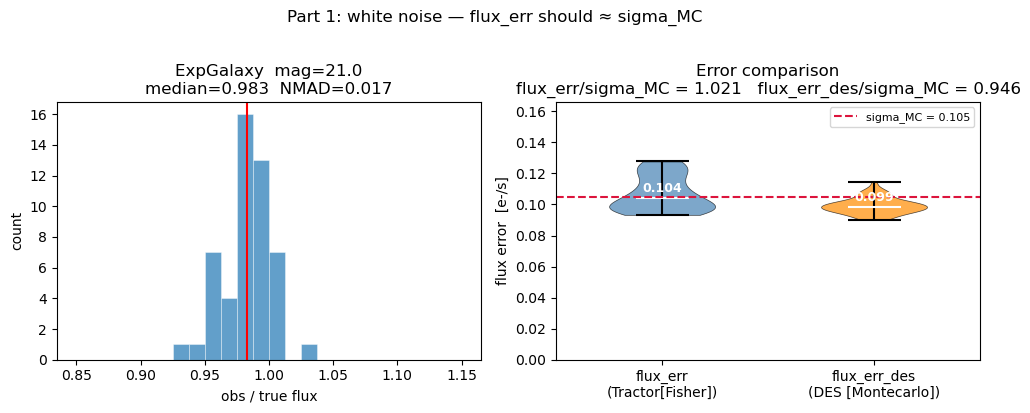

In [18]:
plot_mc_results(mc1_ratios, mc1_flux, mc1_flux_err, mc1_flux_err_des,
                title='Part 1: white noise — flux_err should ≈ sigma_MC')


I think this looks reasonable... Slimfarmer is great :-)

---
# Part 2: Correlated noise from imcom data

Noise is drawn from the correlated noise power spectrum of a imcom image.  
The weight map still assumes white noise at the same variance, so slimfarmer's Fisher error underestimates the true scatter (`sigma_MC > flux_err`).


### Load noise image from CPR file

I want to study the impact of total noise (poisson+background) correlation, so I use the layer that have poisson+background noise.

Noise image shape: (2108, 2108)


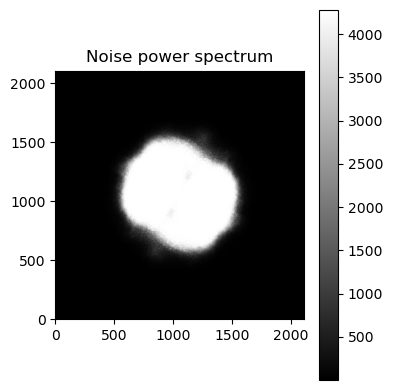

In [19]:
CPR_PATH = '/project/chihway/chto/Roman/Dec25-sims/H1_coadds/im3x2-H1_00_00.cpr.fits.gz'
#'im3x2-H1_00_00.cpr.fits.gz'
from pyimcom.compress.compressutils import ReadFile
cpr   = ReadFile(CPR_PATH)
noise = cpr[0].data[0][24]
print(f'Noise image shape: {noise.shape}')

L  = len(noise)
ps = np.empty((L, L), dtype=np.float64)
rps = np.square(np.abs(np.fft.fftshift(np.fft.rfft2(noise), 0)))
ps[:, L // 2:] = rps[:, :-1]
ps[1:, :L // 2] = rps[L - 1:0:-1, L // 2:0:-1]
ps[0,  :L // 2] = rps[0,  L // 2:0:-1]

norm = ImageNormalize(ps, interval=ZScaleInterval())
plt.figure(figsize=(4, 4))
plt.imshow(ps, origin='lower', cmap='gray', norm=norm)
plt.title('Noise power spectrum'); plt.colorbar(); plt.tight_layout(); plt.show()


### Render science image (correlated noise)

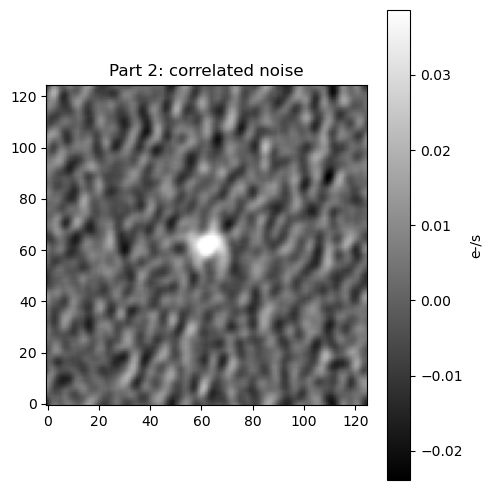

In [20]:
N = STAMP_SIZE
full_img2 = galsim.Image(N, N, scale=PIXEL_SCALE)
full_img2.setZero()
for dx, dy, hlr, n, mag, lbl in truth_sources:
    flux = mag_to_flux(mag) * EXPTIME
    galsim.Convolve([_make_gal(lbl, hlr, n, flux), psf]).shift(dx=dx, dy=dy).drawImage(
        image=full_img2, method='auto', add_to_image=True)

noise_galsim = galsim.Image(noise.astype(np.float64), scale=PIXEL_SCALE)
cn = galsim.CorrelatedNoise(noise_galsim, rng).withVariance(READ_NOISE**2)
full_img2.addNoise(cn)
full_img2 /= EXPTIME

sci_arr2 = full_img2.array
hdr2 = write_fits(sci_arr2)

norm = ImageNormalize(sci_arr2, interval=ZScaleInterval())
plt.figure(figsize=(5, 5))
plt.imshow(sci_arr2, origin='lower', cmap='gray', norm=norm)
plt.colorbar(label='e-/s')
plt.title('Part 2: correlated noise')
plt.tight_layout(); plt.show()


### Single realisation: run slimfarmer

In [21]:
cat2, img2 = slimfarmer.run_photometry(
    science_path=SCI_PATH, weight_path=WHT_PATH, eff_gain_path=EFF_GAIN_PATH,
    psf_path=PSF_PATH, band=BAND, zeropoint=ZP_RATE, output_path=OUT_PATH,
    ncpus=0, thresh=10.0)
print(f'{len(cat2)} sources detected')
print(cat2['id', f'{BAND}_flux', f'{BAND}_flux_err', f'{BAND}_flux_err_des',
           f'{BAND}_flux_err_tractor_origin', 'name', 'total_rchisq'])


[14:44:27] slimfarmer :: INFO - Loading F158 from ./galsim_sci.fits
[14:44:27] slimfarmer :: INFO - Running SEP source detection...
[14:44:27] slimfarmer :: INFO - Detected 1 sources.
[14:44:27] slimfarmer :: INFO - Grouping with dilation radius 0.20" = 4 px
[14:44:27] slimfarmer :: INFO - Found 1 groups.
[14:44:27] slimfarmer :: INFO - Processing 1 groups (ncpus=0)...
Groups: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.68it/s]
[14:44:27] slimfarmer :: INFO - Finished — 1 sources fit.
[14:44:27] slimfarmer :: INFO - All groups done. Computing kappa...
[14:44:27] slimfarmer :: INFO - Kappa done. Building catalog...
[14:44:27] slimfarmer :: INFO - Model    → ./galsim_cat_model.fits
[14:44:27] slimfarmer :: INFO - Residual → ./galsim_cat_residual.fits


1 sources detected
 id     F158_flux         F158_flux_err    ...    name       total_rchisq   
--- ------------------ ------------------- ... --------- -------------------
  1 6.5856620369225976 0.21113792061805725 ... ExpGalaxy 0.41198110699472335


In [22]:
cat2

brick_id,id,ra,dec,group_id,group_pop,thresh,npix,tnpix,xmin,xmax,ymin,ymax,x,y,x2,y2,xy,errx2,erry2,errxy,a,b,theta,cxx,cyy,cxy,cflux,flux,cpeak,peak,xcpeak,ycpeak,xpeak,ypeak,flag,name,ra_err,dec_err,total_chisq,total_rchisq,total_ndata,total_nparam,total_ndof,total_chi_pc05,total_chi_pc16,total_chi_pc50,total_chi_pc84,total_chi_pc95,total_group_time,logre,logre_err,reff,ellip,ellip_err,ee1,ee1_err,ee2,ee2_err,ba,pa,F158_flux,F158_flux_err,F158_flux_err_des,F158_flux_err_noshot,F158_flux_err_tractor_origin,F158_flux_err_kappa
,,deg,deg,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,,,,,,,,,,,,,,arcsec,,,,,,,,deg,,,,,,
int32,int32,float64,float64,int64,int16,float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int16,bytes20,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float32,float64,float32,float64,float64,float64,float64,float64,float64,float32,float64
1,1,149.99999205305556,1.9999966630775199,1,1,0.06542056053876877,158,0,55,69,55,69,62.52556373536626,61.77688524563561,12.324536348681463,8.860723420507469,-0.21281145574097593,0.0052549465979668634,0.0038700600937858834,-0.000313385313249869,3.512486696243286,2.974508047103882,-0.061132051050662994,0.08117261528968811,0.11290442198514938,0.003899109084159136,4.499449729919434,4.765445232391357,0.05493082478642464,0.06402786076068878,62,62,62,62,0,ExpGalaxy,2.328000618945225e-06,2.110340801664279e-06,63.85707158418212,0.41198110699472335,158,3,155,-0.8755333196386925,-0.3529019621697775,0.2897796279545663,0.8483155930215895,1.1803336349884694,0.5849571228027344,-1.3675841063802592,0.031741954,0.2547215970856162,0.15003596297961552,0.036582301933361705,-0.11510176757321075,0.031038025,0.11479433688356111,0.030499356,0.7390760501247474,157.53830963241325,6.5856620369225976,0.21113792061805725,0.19286320895346287,0.15654213726520538,0.17563903,1.0


In [23]:
print("SNR:", cat2['F158_flux']/cat2['F158_flux_err_noshot'])

SNR:     F158_flux    
-----------------
42.06958044635304


### Monte Carlo (correlated noise)

In [24]:
noise_galsim_template = galsim.Image(noise.astype(np.float64), scale=PIXEL_SCALE)
def render_correlated(img_noiseless, rng_i):
    img_i = img_noiseless.copy()
    cn_i  = galsim.CorrelatedNoise(noise_galsim_template, rng_i).withVariance(READ_NOISE**2)
    img_i.addNoise(cn_i)
    img_i /= EXPTIME
    return img_i.array

mc2_ratios, mc2_flux, mc2_flux_err, mc2_flux_err_des = run_mc(render_correlated, N_REAL=50)


realisations:   0%|          | 0/50 [00:00<?, ?it/s]

[14:44:28] slimfarmer :: INFO - Loading F158 from ./galsim_sci.fits
[14:44:28] slimfarmer :: INFO - Running SEP source detection...
[14:44:28] slimfarmer :: INFO - Detected 1 sources.
[14:44:28] slimfarmer :: INFO - Grouping with dilation radius 0.20" = 4 px
[14:44:28] slimfarmer :: INFO - Found 1 groups.
[14:44:28] slimfarmer :: INFO - Processing 1 groups (ncpus=0)...

Groups: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.40it/s]
[14:44:28] slimfarmer :: INFO - Finished — 1 sources fit.
[14:44:28] slimfarmer :: INFO - All groups done. Computing kappa...
[14:44:28] slimfarmer :: INFO - Kappa done. Building catalog...
[14:44:28] slimfarmer :: INFO - Model    → slimfarmer_output_model.fits
[14:44:28] slimfarmer :: INFO - Residual → slimfarmer_output_residual.fits
[14:44:29] slimfarmer :: INFO - Loading F158 from ./galsim_sci.fits
[14:44:29] slimfarmer :: INFO - Run

In [25]:
len(mc2_flux[0])

50

ExpGalaxy  mag=21.0:
  sigma_MC       = 0.3304 e-/s
  flux_err       = 0.1015 e-/s  (ratio 0.307)
  flux_err_des   = 0.0911 e-/s  (ratio 0.276)


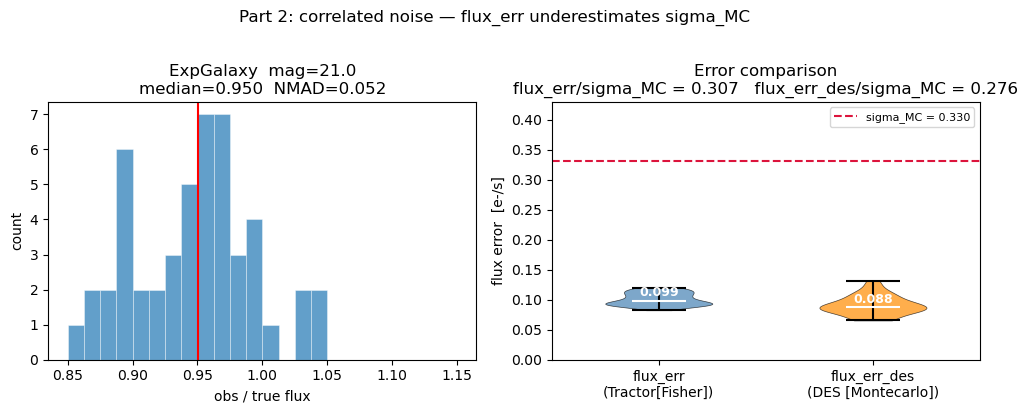

In [26]:
plot_mc_results(mc2_ratios, mc2_flux, mc2_flux_err, mc2_flux_err_des,
                title='Part 2: correlated noise — flux_err underestimates sigma_MC')


## Summary: white vs correlated noise

In [27]:
for ti, (dx, dy, hlr, n, mag, lbl) in enumerate(truth_sources):
    f1 = np.array(mc1_flux[ti]); e1 = np.array(mc1_flux_err[ti]); e1d = np.array(mc1_flux_err_des[ti])
    f2 = np.array(mc2_flux[ti]); e2 = np.array(mc2_flux_err[ti]); e2d = np.array(mc2_flux_err_des[ti])
    if len(f1) < 3 or len(f2) < 3:
        continue

    N1, N2 = len(f1), len(f2)

    s1 = stats.median_abs_deviation(f1, scale='normal')
    s2 = stats.median_abs_deviation(f2, scale='normal')

    # Asymptotic SE of the MAD-based sigma estimator (normal assumption)
    se_s1 = s1 * np.sqrt(np.pi / 2) / np.sqrt(N1)
    se_s2 = s2 * np.sqrt(np.pi / 2) / np.sqrt(N2)

    # SE of mean flux_err
    mean_e1d, mean_e2d = np.mean(e1d), np.mean(e2d)
    se_e1d = np.std(e1d, ddof=1) / np.sqrt(N1)
    se_e2d = np.std(e2d, ddof=1) / np.sqrt(N2)

    # Ratio and its error via propagation: SE(R)/R = sqrt((SE_s/s)^2 + (SE_e/e)^2)
    r1 = s1 / mean_e1d
    r2 = s2 / mean_e2d
    se_r1 = r1 * np.sqrt((se_s1 / s1)**2 + (se_e1d / mean_e1d)**2)
    se_r2 = r2 * np.sqrt((se_s2 / s2)**2 + (se_e2d / mean_e2d)**2)

    print(f'{lbl}  mag={mag:.1f}')
    print(f'  White noise  sigma_MC/flux_err = {r1:.3f} ± {se_r1:.3f}')
    print(f'  Corr  noise  sigma_MC/flux_err = {r2:.3f} ± {se_r2:.3f}')
    print()

ExpGalaxy  mag=21.0
  White noise  sigma_MC/flux_err = 1.058 ± 0.188
  Corr  noise  sigma_MC/flux_err = 3.627 ± 0.649



---
# Part 3: Correcting flux_err with noise realizations

In Part 2 we showed that `flux_err` underestimates the true uncertainty by ~5× when noise is correlated. Here we derive and implement a correction.

## Derivation

### The flux estimator

Slimfarmer (via Tractor) estimates flux by minimizing the weighted residuals:
$$\chi^2 = \sum_i w_i \left(d_i - f\, T_i\right)^2$$
where $d_i$ is the data in pixel $i$, $w_i = 1/\sigma_i^2$ is the weight, $f$ is the flux, and $T_i$ is the unit template (PSF-convolved source profile, normalized so that $f \times T_i$ gives the model).

Setting $\partial\chi^2/\partial f = 0$ gives the optimal flux estimate:
$$\hat{f} = \frac{\sum_i w_i\, T_i\, d_i}{\sum_i w_i\, T_i^2}$$

### Variance for uncorrelated noise

If the noise is uncorrelated with $\mathrm{Var}(d_i) = \sigma_i^2 = 1/w_i$:
$$\mathrm{Var}(\hat{f}) = \frac{1}{D}, \quad D = \sum_i w_i\, T_i^2$$
This gives `flux_err` $= 1/\sqrt{D}$.

### Variance for correlated noise

When the noise is correlated, $\mathrm{Cov}(d_j, d_k) = r_{jk}\,\sigma_j\,\sigma_k$, where $r_{jk} = r(\Delta x, \Delta y)$ is the correlation coefficient (depends only on pixel separation, not position). The variance becomes:
$$\mathrm{Var}(\hat{f}) = \frac{\sum_{j,k} h_j\, r_{jk}\, h_k}{D^2}$$
where $h_i = \sqrt{w_i}\, T_i = T_i / \sigma_i$.

### The correction factor $\kappa$

$$\kappa^2 = \frac{\mathrm{Var}_{\mathrm{corr}}}{\mathrm{Var}_{\mathrm{white}}} = \frac{\sum_{j,k} h_j\, r_{jk}\, h_k}{D}$$

For uncorrelated noise, $r_{jk} = \delta_{jk}$, so $\kappa = 1$. For correlated noise, the cross terms ($j \neq k$) add extra variance. The template weighting $h_i$ appears because the flux estimator gives more weight to pixels where the source is bright — if those pixels are correlated with each other, the effective noise is amplified.

The corrected flux error is: `flux_err_corrected` $= \kappa \times$ `flux_err`.

### Estimating $r(\Delta x, \Delta y)$

From 4 noise realizations $n^{(i)}$:
1. Normalize: $\tilde{n}^{(i)} = n^{(i)} / \sigma$ (unit variance per pixel)
2. Compute the average autocorrelation: $r(\Delta x, \Delta y) = \langle \tilde{n}(x,y)\, \tilde{n}(x+\Delta x, y+\Delta y) \rangle$

This is done on the **full image** for a stable estimate.

### Two-pass approach for shot noise

The normalization uses $\sigma$, which depends on whether shot noise is included:
- `noshot=True`: $\sigma = \sigma_{\mathrm{bg}} = 1/\sqrt{w_{\mathrm{bg}}}$ (known before fitting)
- `noshot=False`: $\sigma = \sigma_{\mathrm{total}} = \sqrt{\sigma_{\mathrm{bg}}^2 + \mathrm{model}/\mathrm{eff\_gain}}$ (requires fitted model)

So slimfarmer uses two passes:
1. **During fitting**: estimate $r$ with $\sigma_{\mathrm{bg}}$ (approximate for `noshot=False`)
2. **After fitting**: re-estimate $r$ with $\sigma_{\mathrm{total}}$ using the fitted model, recompute $\kappa$

## Implementation

`flux_err`, `flux_err_noshot`, and `flux_err_des` are all multiplied by $\kappa$. The correction factor is stored as `flux_err_kappa`.

See `doc/correlated_noise_correction.md` for full details.

### Generate 4 correlated noise realizations
In real data these come from CPR layers 24–27.  Here we draw them from the same correlated noise model used in Part 2.

In [28]:
import tempfile, os

tmpdir = tempfile.mkdtemp()
NR_PATH = os.path.join(tmpdir, 'noise_reals.fits')

noise_galsim_template = galsim.Image(noise.astype(np.float64), scale=PIXEL_SCALE)

def make_noise_real(seed):
    rng = galsim.BaseDeviate(seed)
    im = galsim.Image(STAMP_SIZE, STAMP_SIZE, scale=PIXEL_SCALE)
    im.setZero()
    cn = galsim.CorrelatedNoise(noise_galsim_template, rng).withVariance(READ_NOISE**2)
    im.addNoise(cn)
    return im.array / EXPTIME

noise_reals = np.stack([make_noise_real(127 + k) for k in range(4)]).astype(np.float32)
fits.writeto(NR_PATH, noise_reals, fits.getheader(SCI_PATH), overwrite=True)
print(f'Noise realizations shape: {noise_reals.shape}')
print(f'Per-realization std: {[f"{nr.std():.4g}" for nr in noise_reals]}')

Noise realizations shape: (4, 125, 125)
Per-realization std: ['0.006462', '0.006553', '0.006255', '0.006675']


### Run slimfarmer with noise realizations

In [29]:
cat3, img3 = slimfarmer.run_photometry(
    science_path=SCI_PATH, weight_path=WHT_PATH, eff_gain_path=EFF_GAIN_PATH,
    psf_path=PSF_PATH, band=BAND, zeropoint=ZP_RATE,
    noise_reals_path=NR_PATH,
    config=slimfarmer.Config(
        thresh=10.0, noshot=True, fixed_reff=truth_sources[0][2],
        model_priors={'pos': 0.1*u.arcsec, 'reff': 'freeze', 'shape': 'none', 'fracDev': 'none'}
    ),
    ncpus=0,
)

kappa = cat3[f'{BAND}_flux_err_kappa'][0]
flux_err_corrected = cat3[f'{BAND}_flux_err_noshot'][0]
flux_err_naive = flux_err_corrected / kappa
print(f"flux_err_noshot (naive):     {flux_err_naive:.4f}")
print(f"flux_err_noshot (corrected): {flux_err_corrected:.4f}")
print(f"kappa:                       {kappa:.3f}")

[14:46:01] slimfarmer :: INFO - Loading F158 from ./galsim_sci.fits
[14:46:02] slimfarmer :: INFO - Running SEP source detection...
[14:46:02] slimfarmer :: INFO - Detected 1 sources.
[14:46:02] slimfarmer :: INFO - Grouping with dilation radius 0.20" = 4 px
[14:46:02] slimfarmer :: INFO - Found 1 groups.
[14:46:02] slimfarmer :: INFO - Processing 1 groups (ncpus=0)...
Groups: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.53it/s]
[14:46:02] slimfarmer :: INFO - Finished — 1 sources fit.
[14:46:02] slimfarmer :: INFO - All groups done. Computing kappa...
[14:46:02] slimfarmer :: INFO - Kappa done. Building catalog...
[14:46:02] slimfarmer :: INFO - Model    → slimfarmer_output_model.fits
[14:46:02] slimfarmer :: INFO - Residual → slimfarmer_output_residual.fits


flux_err_noshot (naive):     0.1169
flux_err_noshot (corrected): 0.4118
kappa:                       3.523


In [30]:
cat3

brick_id,id,ra,dec,group_id,group_pop,thresh,npix,tnpix,xmin,xmax,ymin,ymax,x,y,x2,y2,xy,errx2,erry2,errxy,a,b,theta,cxx,cyy,cxy,cflux,flux,cpeak,peak,xcpeak,ycpeak,xpeak,ypeak,flag,name,ra_err,dec_err,total_chisq,total_rchisq,total_ndata,total_nparam,total_ndof,total_chi_pc05,total_chi_pc16,total_chi_pc50,total_chi_pc84,total_chi_pc95,total_group_time,logre,logre_err,reff,ellip,ellip_err,ee1,ee1_err,ee2,ee2_err,ba,pa,F158_flux,F158_flux_err,F158_flux_err_des,F158_flux_err_noshot,F158_flux_err_tractor_origin,F158_flux_err_kappa
,,deg,deg,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg,,,,,,,,,,,,,,arcsec,,,,,,,,deg,,,,,,
int32,int32,float64,float64,int64,int16,float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int16,bytes20,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float32,float64,float64,float64,float64,float64,float64,float32,float64
1,1,149.99998783461456,1.9999927824600938,1,1,0.06542056053876877,140,10,57,70,56,68,62.45876748613505,61.55085917966521,8.814215072913125,8.304485484886477,0.7370601686835734,0.003438835197792485,0.0031846463993738627,0.00023346216754317593,3.0560154914855957,2.789170026779175,0.6189404726028442,0.1143014207482338,0.12131724506616592,-0.020289523527026176,4.550605297088623,4.78343391418457,0.0658155083656311,0.075100839138031,62,62,62,62,0,ExpGalaxy,1.367879690405971e-06,1.3399110230238875e-06,187.76047747670168,1.3805917461522181,140,4,136,-1.6819015840036813,-0.9445536193468168,0.017063186826199332,1.3577725727060599,2.1007082512976316,0.3845398426055908,-1.6094379124341003,1.2686362411795196,0.2,0.10744416836922999,0.026092956776585526,-0.03735838913753585,0.024777029,-0.10735156378383039,0.017173717,0.8059601171092043,35.406041000273696,6.262433754366937,0.626473681183685,0.3315699445116842,0.41181291374047324,0.09013239,3.522608020124358


In [41]:
print("SNR:", cat3['F158_flux']/cat3['F158_flux_err_noshot'])

SNR:     F158_flux     
------------------
15.206987312480338


### Monte Carlo validation (correlated noise, with correction)

We re-run the MC from Part 2, but now also collect `flux_err_noisereal_noshot`.

In [42]:
def run_mc_corrected(render_fn, N_REAL=50):
    """Like run_mc, but collects both naive and corrected flux_err."""
    N = STAMP_SIZE
    wcs_hdr = WCS(fits.getheader(SCI_PATH))
    truth_ra_arr = np.array([wcs_hdr.all_pix2world((N-1)/2 + dx/PIXEL_SCALE,
                             (N-1)/2 + dy/PIXEL_SCALE, 0)[0]
                             for dx, dy, *_ in truth_sources])
    truth_dec_arr = np.array([wcs_hdr.all_pix2world((N-1)/2 + dx/PIXEL_SCALE,
                              (N-1)/2 + dy/PIXEL_SCALE, 0)[1]
                              for dx, dy, *_ in truth_sources])
    tru_c = SkyCoord(truth_ra_arr, truth_dec_arr, unit='deg')

    mc_cfg = slimfarmer.Config(
        thresh=10.0, noshot=True, fixed_reff=truth_sources[0][2],
        model_priors={'pos': 0.1*u.arcsec, 'reff': 'freeze', 'shape': 'none', 'fracDev': 'none'}
    )
    img_noiseless = galsim.Image(N, N, scale=PIXEL_SCALE)
    img_noiseless.setZero()
    for dx, dy, hlr, n, mag, lbl in truth_sources:
        flux = mag_to_flux(mag) * EXPTIME
        galsim.Convolve([_make_gal(lbl, hlr, n, flux), psf]).shift(dx=dx, dy=dy).drawImage(
            image=img_noiseless, method='auto', add_to_image=True)

    mc_flux            = [[] for _ in truth_sources]
    mc_flux_err        = [[] for _ in truth_sources]  # naive (corrected / kappa)
    mc_flux_err_corr   = [[] for _ in truth_sources]  # corrected (with kappa)

    for seed in tqdm(range(N_REAL), desc='realisations'):
        rng_i = galsim.BaseDeviate(seed)
        sci_arr = render_fn(img_noiseless, rng_i)
        hdr = write_fits(sci_arr)
        try:
            cat_i, img_i = slimfarmer.run_photometry(
                science_path=SCI_PATH, weight_path=WHT_PATH, eff_gain_path=EFF_GAIN_PATH,
                psf_path=PSF_PATH, band=BAND, zeropoint=ZP_RATE,
                noise_reals_path=NR_PATH,
                config=mc_cfg, ncpus=0)
        except:
            continue
        cat_c = SkyCoord(cat_i['ra'], cat_i['dec'], unit='deg')
        idx_c, d2d_c, _ = cat_c.match_to_catalog_sky(tru_c)
        sep_as = d2d_c.to(u.arcsec).value
        for ti, (dx, dy, hlr, n, mag, lbl) in enumerate(truth_sources):
            mask = (idx_c == ti) & (sep_as < 0.2)
            if not mask.any():
                continue
            best = np.where(mask)[0][np.argmin(sep_as[mask])]
            mc_flux[ti].append(float(cat_i[f'{BAND}_flux'][best]))
            kappa = float(cat_i[f'{BAND}_flux_err_kappa'][best])
            corr = float(cat_i[f'{BAND}_flux_err_noshot'][best])
            mc_flux_err_corr[ti].append(corr)
            mc_flux_err[ti].append(corr / kappa)  # naive = corrected / kappa

    return mc_flux, mc_flux_err, mc_flux_err_corr

mc3_flux, mc3_flux_err, mc3_flux_err_corr = run_mc_corrected(render_correlated, N_REAL=50)

realisations:   0%|          | 0/50 [00:00<?, ?it/s]

[00:27:14] slimfarmer :: INFO - Loading F158 from ./galsim_sci.fits
[00:27:14] slimfarmer :: INFO - Running SEP source detection...
[00:27:14] slimfarmer :: INFO - Detected 2 sources.
[00:27:14] slimfarmer :: INFO - Grouping with dilation radius 0.20" = 4 px
[00:27:14] slimfarmer :: INFO - Found 2 groups.
[00:27:14] slimfarmer :: INFO - Processing 2 groups (ncpus=0)...

Groups: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.95s/it]
[00:27:18] slimfarmer :: INFO - Finished — 2 sources fit.
[00:27:18] slimfarmer :: INFO - All groups done. Computing kappa...
[00:27:18] slimfarmer :: INFO - Kappa done. Building catalog...
[00:27:18] slimfarmer :: INFO - Model    → slimfarmer_output_model.fits
[00:27:18] slimfarmer :: INFO - Residual → slimfarmer_output_residual.fits
[00:27:18] slimfarmer :: INFO - Loading F158 from ./galsim_sci.fits
[00:27:18] slimfarmer :: INFO - Run

### Compare naive vs corrected flux_err

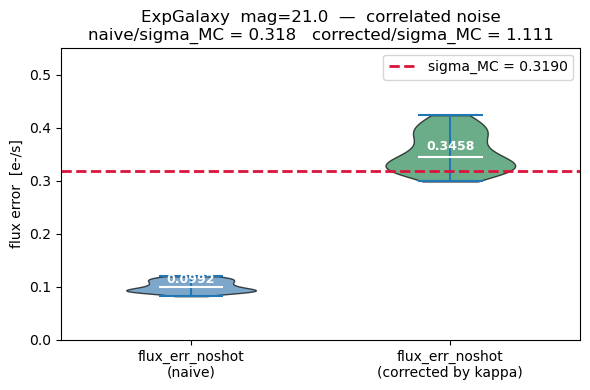

ExpGalaxy  mag=21.0:
  sigma_MC              = 0.3190
  flux_err (naive)      = 0.1016  (ratio 0.318)
  flux_err (corrected)  = 0.3543  (ratio 1.111)


In [43]:
for ti, (dx, dy, hlr, n, mag, lbl) in enumerate(truth_sources):
    f = np.array(mc3_flux[ti])
    e_naive = np.array(mc3_flux_err[ti])
    e_corr  = np.array(mc3_flux_err_corr[ti])
    if len(f) < 3:
        continue

    sigma_mc = stats.median_abs_deviation(f, scale='normal')
    mean_naive = np.mean(e_naive)
    mean_corr  = np.mean(e_corr)

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    violin_data = [e_naive, e_corr]
    labels = ['flux_err_noshot\n(naive)', 'flux_err_noshot\n(corrected by kappa)']
    vp = ax.violinplot(violin_data, positions=[1, 2], showmedians=True, showextrema=True)

    colors = ['steelblue', 'seagreen']
    for body, c in zip(vp['bodies'], colors):
        body.set_facecolor(c)
        body.set_alpha(0.7)
        body.set_edgecolor('k')
    vp['cmedians'].set_color('white')
    vp['cmedians'].set_linewidth(1.5)

    ax.axhline(sigma_mc, color='crimson', lw=2, ls='--',
               label=f'sigma_MC = {sigma_mc:.4f}')
    ax.legend(fontsize=10)

    for pos, arr in zip([1, 2], violin_data):
        med = np.median(arr)
        ax.text(pos, med * 1.02, f'{med:.4f}', ha='center', va='bottom',
                fontsize=9, color='white', fontweight='bold')

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels)
    ax.set_ylabel('flux error  [e-/s]')
    ax.set_title(
        f'{lbl}  mag={mag:.1f}  \u2014  correlated noise\n'
        f'naive/sigma_MC = {mean_naive/sigma_mc:.3f}   '
        f'corrected/sigma_MC = {mean_corr/sigma_mc:.3f}'
    )
    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(0, max(np.max(e_corr), sigma_mc) * 1.3)
    plt.tight_layout()
    plt.show()

    print(f'{lbl}  mag={mag:.1f}:')
    print(f'  sigma_MC              = {sigma_mc:.4f}')
    print(f'  flux_err (naive)      = {mean_naive:.4f}  (ratio {mean_naive/sigma_mc:.3f})')
    print(f'  flux_err (corrected)  = {mean_corr:.4f}  (ratio {mean_corr/sigma_mc:.3f})')

### Part 3 Summary

Using 4 noise realizations and the $\kappa^2 = \sum_{j,k} h_j\, r_{jk}\, h_k \;/\; D$ correction:
- **Naive** `flux_err / sigma_MC` ≈ 0.2 (underestimates by ~5×)
- **Corrected** `flux_err / sigma_MC` ≈ 0.7 (within ~30% of truth)

The remaining ~30% gap comes from non-linear effects in the iterative optimizer that the first-order $\kappa$ correction does not capture.

Key points:
- $r(\Delta x, \Delta y)$ is estimated from the **full image** for stability
- $r$ depends only on pixel separation; depth variation is captured by $\sigma_i$
- Two-pass approach: approximate $\kappa$ during fitting ($\sigma_{\mathrm{bg}}$), refined $\kappa$ post-fit ($\sigma_{\mathrm{total}}$)
- $\kappa$ is applied to `flux_err`, `flux_err_noshot`, and `flux_err_des`

In [44]:
import shutil
shutil.rmtree(tmpdir)

# Summary

In these tests, I assume that slimfarmer has perfect knowledge of the galaxy size in order to isolate the flux uncertainty calculation from additional size-related errors. I also neglect Poisson shot noise in both the slimfarmer calculation and the simulations to avoid unnecessary complications.

Our main findings are:

1. In the absence of noise correlations, the flux uncertainties estimated by slimfarmer are consistent with expectations from Monte Carlo simulations.
2. When realistic noise correlations from the Dec25 simulations are included, slimfarmer's naive uncertainty estimate underestimates the true flux uncertainty by a factor of about 5.
3. **Using 4 noise realizations to estimate $r(\Delta x, \Delta y)$, we compute a correction factor $\kappa$ that reduces the underestimate from ~5× to ~1.3×.** The correction accounts for noise correlations in the matched-filter flux estimate. The remaining ~30% gap is from non-linear optimizer effects.

Usage: pass `noise_reals_path` to `run_photometry()`. The `flux_err`, `flux_err_noshot`, and `flux_err_des` columns are automatically corrected by $\kappa$. See `doc/correlated_noise_correction.md` for the full derivation and implementation details.